<a href="https://colab.research.google.com/github/goravmeghani/Hello/blob/main/Global_Ecological_Footprint_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset Loading**

In [ ]:
import pandas as pd

# Load the dataset from the provided URL with explicit encoding
url = '/content/Global Ecological Footprint 2023.csv'
data = pd.read_csv(url, encoding='latin1')


# **Preprocessing of Dataset**



In [ ]:
# Convert Data Types
data['Population (millions)'] = pd.to_numeric(data['Population (millions)'].str.replace(',', ''), errors='coerce')
data['Per Capita GDP'] = pd.to_numeric(data['Per Capita GDP'].str.replace('[\$,]', '', regex=True), errors='coerce')

# Handling Missing Values
numerical_cols = [
    'Life Exectancy', 'HDI', 'Per Capita GDP', 'SDGi', 'Population (millions)',
    'Cropland Footprint', 'Grazing Footprint', 'Forest Product Footprint',
    'Carbon Footprint', 'Fish Footprint', 'Built up land', 'Total Ecological Footprint (Consumption)',
    'Cropland', 'Grazing land', 'Forest land', 'Fishing ground', 'Built up land.1',
    'Total biocapacity ', 'Ecological (Deficit) or Reserve', 'Number of Earths required', 'Number of Countries required'
]
data[numerical_cols] = data[numerical_cols].apply(pd.to_numeric, errors='coerce')
data[numerical_cols] = data[numerical_cols].fillna(data[numerical_cols].mean())

categorical_cols = ['Income Group']
data[categorical_cols] = data[categorical_cols].fillna(data[categorical_cols].mode().iloc[0])
data['Income Group'] = pd.Categorical(data['Income Group'])


# Display the updated data info
print(data.info())

data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 24 columns):
 #   Column                                    Non-Null Count  Dtype   
---  ------                                    --------------  -----   
 0   Country                                   182 non-null    object  
 1   Region                                    182 non-null    object  
 2   SDGi                                      182 non-null    float64 
 3   Life Exectancy                            182 non-null    float64 
 4   HDI                                       182 non-null    float64 
 5   Per Capita GDP                            182 non-null    float64 
 6   Income Group                              182 non-null    category
 7   Population (millions)                     182 non-null    float64 
 8   Cropland Footprint                        182 non-null    float64 
 9   Grazing Footprint                         182 non-null    float64 
 10  Forest Product Footprint  

,Country,Region,SDGi,Life Exectancy,HDI,Per Capita GDP,Income Group,Population (millions),Cropland Footprint,Grazing Footprint,...,Total Ecological Footprint (Consumption),Cropland,Grazing land,Forest land,Fishing ground,Built up land.1,Total biocapacity,Ecological (Deficit) or Reserve,Number of Earths required,Number of Countries required
0,Afghanistan,Middle East/Central Asia,52.500000,62.0,0.48,21139.533742,LI,40.8,0.400000,0.100000,...,0.8,0.300000,0.100000,0.012981,0.000565,0.028232,0.513827,-0.287638,0.530696,1.559795
1,Albania,Other Europe,71.600000,76.0,0.80,14889.000000,UM,2.9,0.800000,0.200000,...,2.1,0.600000,0.200000,0.223326,0.081392,0.073006,1.176752,-0.894486,1.371485,1.760131
2,Algeria,Africa,71.500000,76.0,0.75,11137.000000,UM,45.4,0.700000,0.200000,...,2.2,0.400000,0.200000,0.023912,0.007179,0.037775,0.663375,-1.559593,1.471955,3.350998
3,Angola,Africa,50.900000,62.0,0.59,6304.000000,LM,35.0,0.200000,0.100000,...,0.9,0.200000,0.800000,0.416888,0.153499,0.061360,1.588191,0.730346,0.568029,0.540140
4,Antigua and Barbuda,Central America/Caribbean,65.016456,78.0,0.79,18749.000000,HI,0.1,0.582895,0.270395,...,2.9,0.510526,0.402632,1.523629,0.431970,0.088023,0.917277,-2.019458,1.944580,3.201578


# 1.Individual plots for each feature against the target variable.

# 2.Pairwise scatter plots for a subset of features.

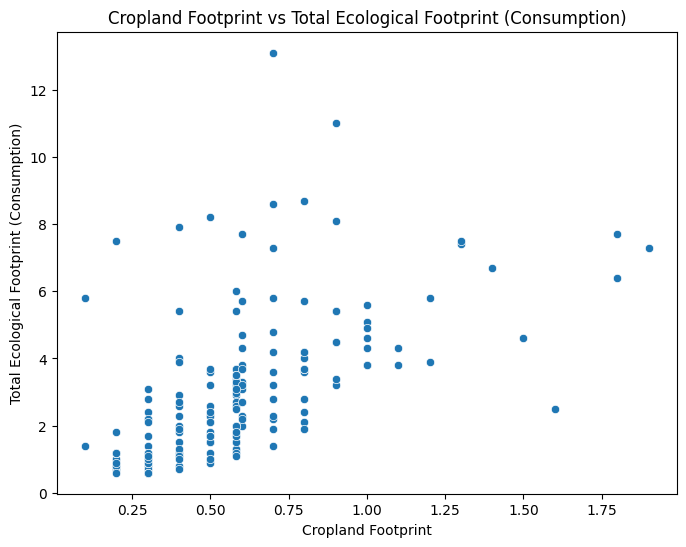

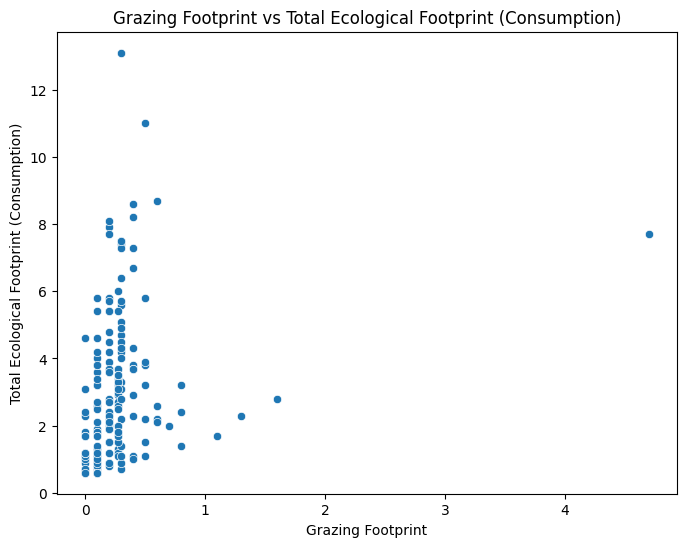

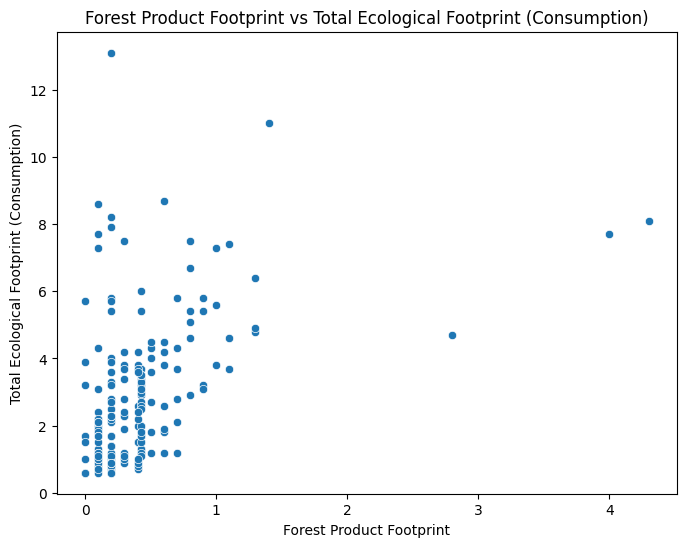

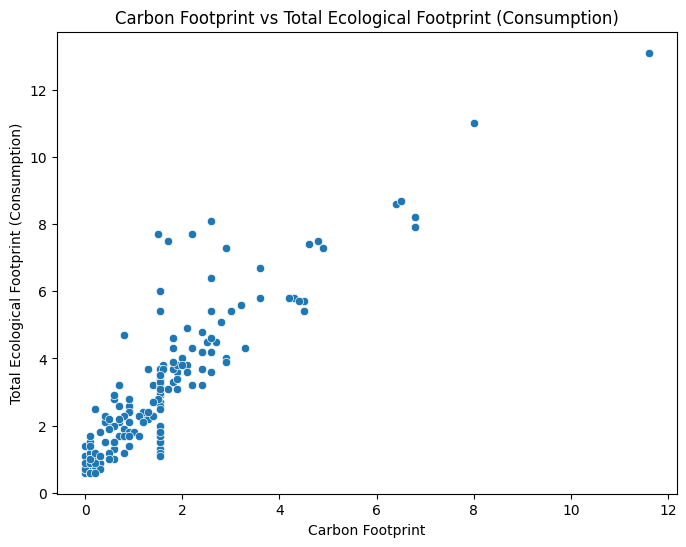

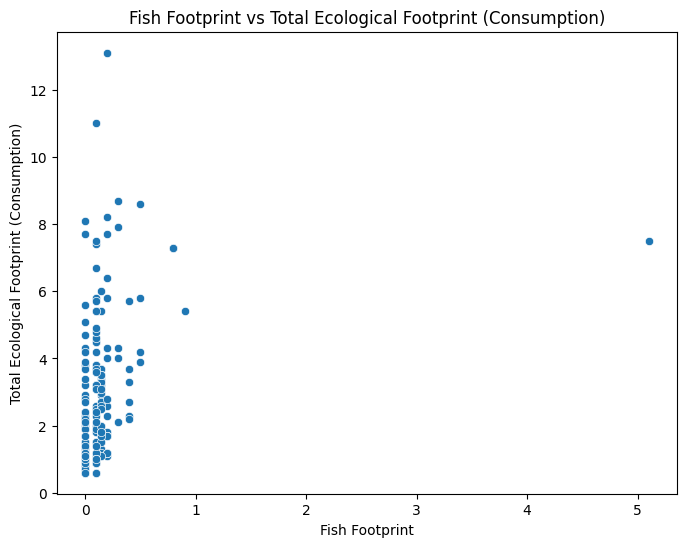

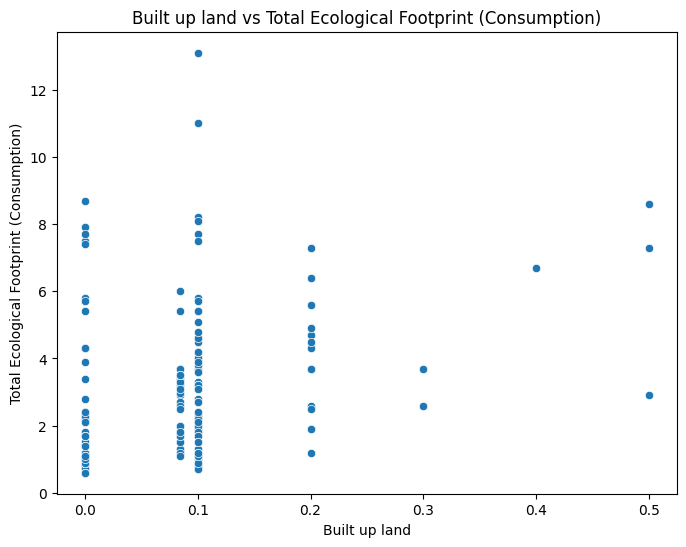

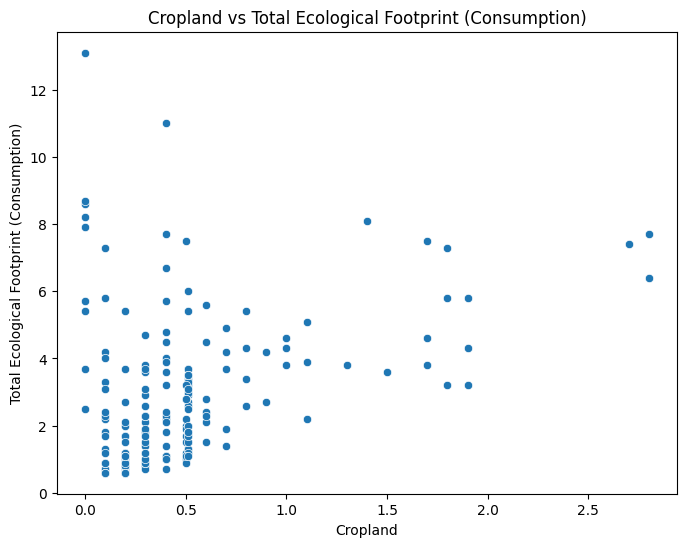

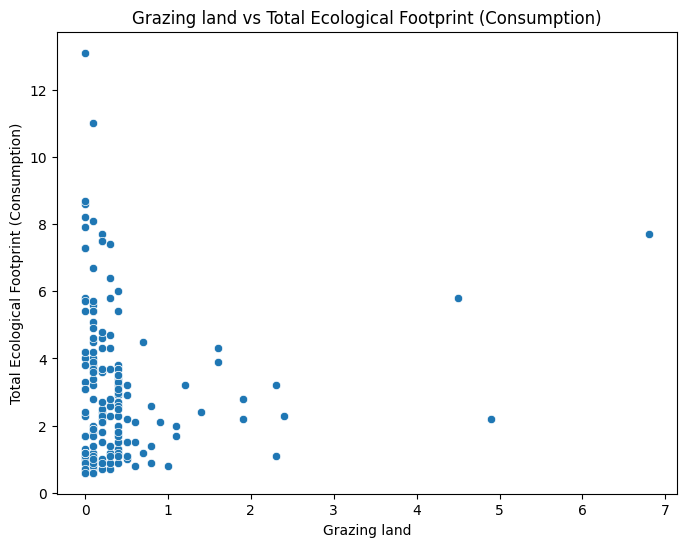

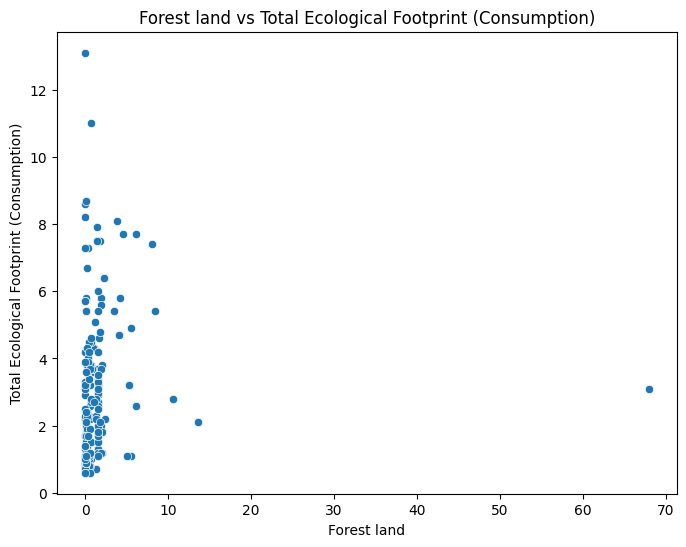

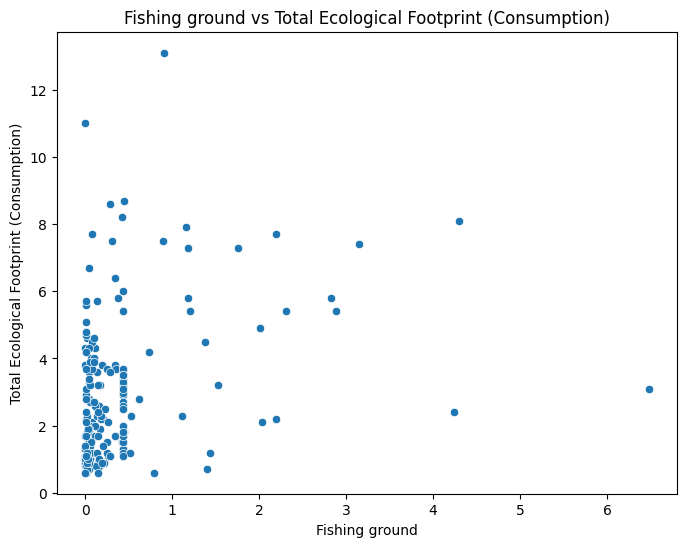

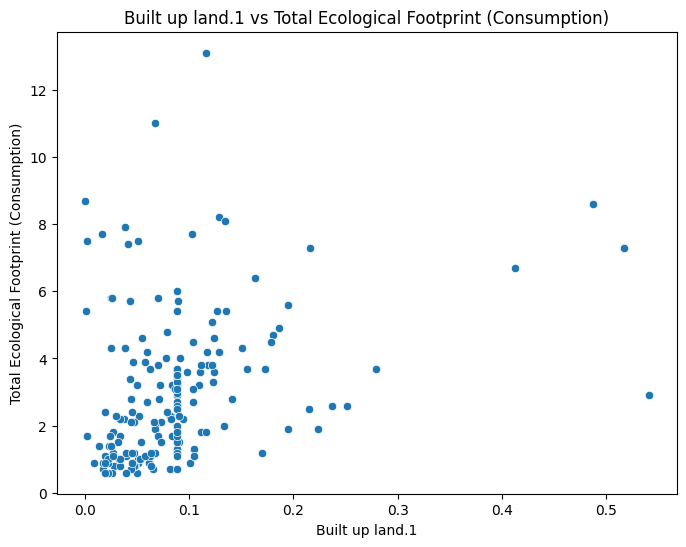

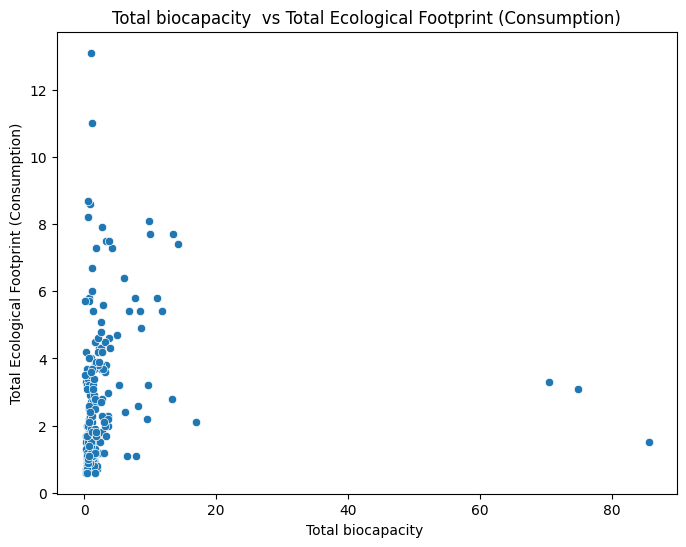

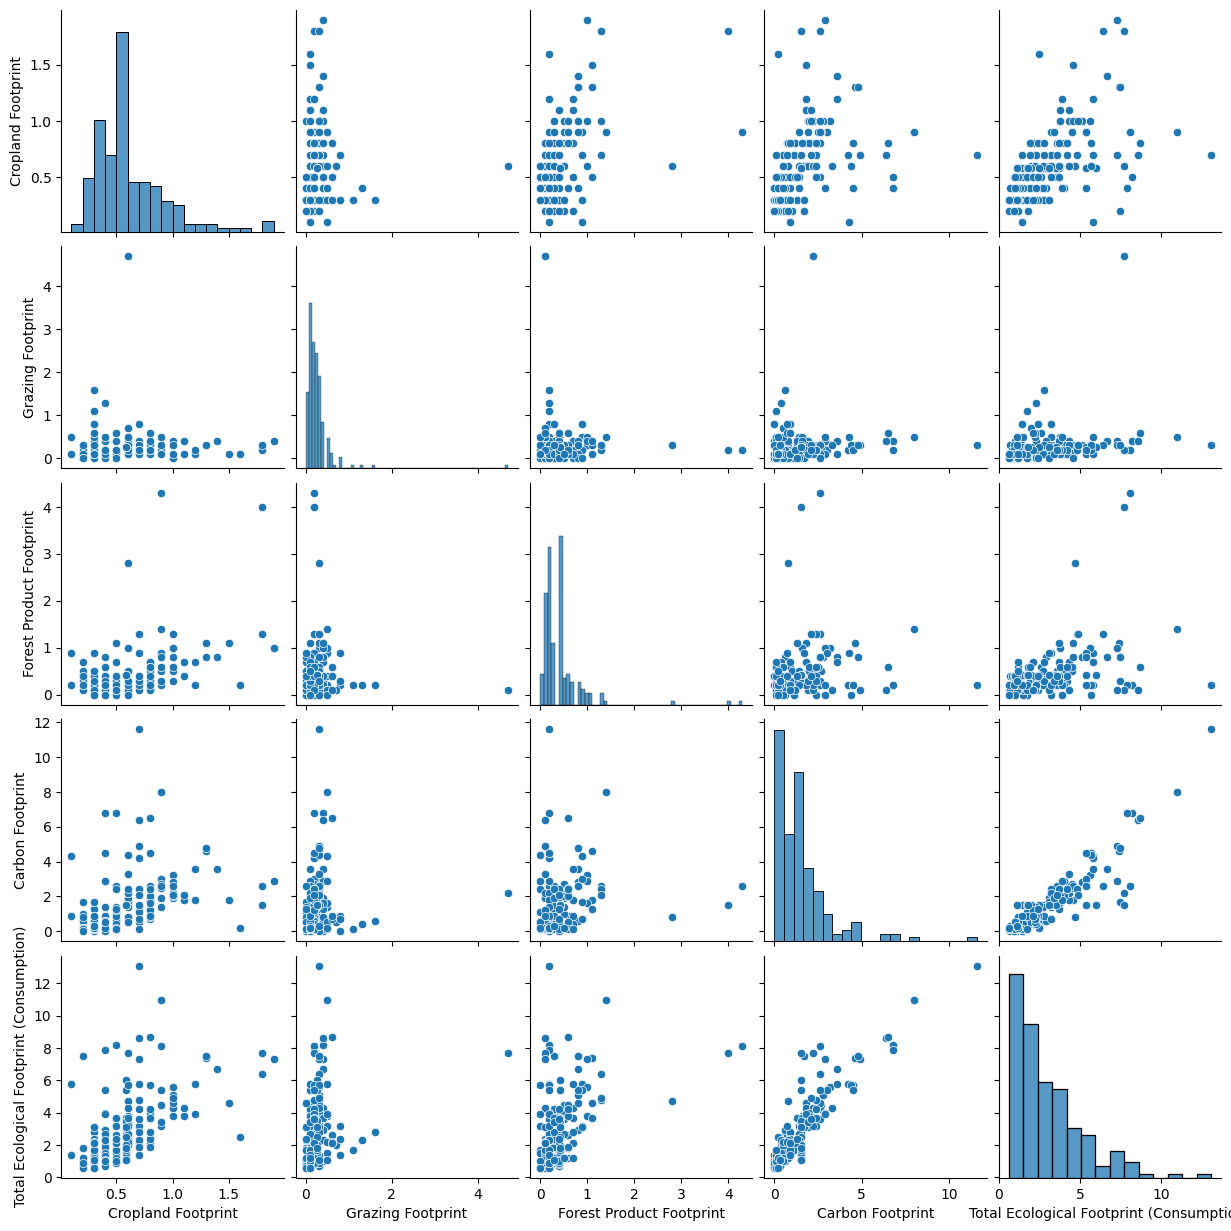

In [ ]:
import seaborn as sns

# Individual plots for each feature against the target variable
for feature in features.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=features[feature], y=target)
    plt.title(f"{feature} vs Total Ecological Footprint (Consumption)")
    plt.xlabel(feature)
    plt.ylabel("Total Ecological Footprint (Consumption)")
    plt.show()

# Pairwise scatter plots for a subset of features
sns.pairplot(data[["Cropland Footprint", "Grazing Footprint", "Forest Product Footprint", "Carbon Footprint", "Total Ecological Footprint (Consumption)"]])
plt.show()


# **Correlation Matrix**

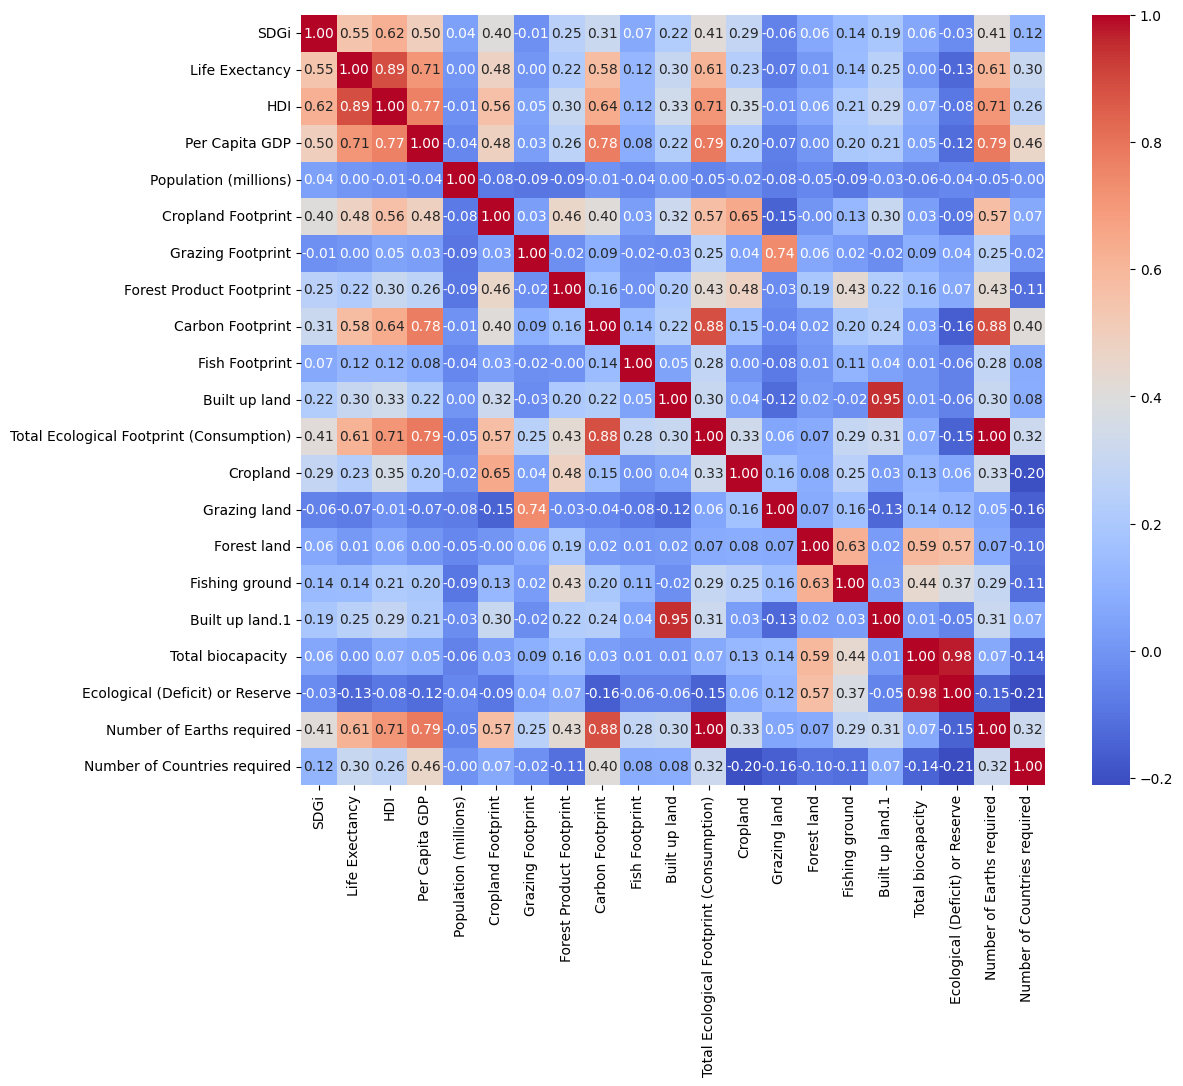

Total Ecological Footprint (Consumption)    1.000000
Number of Earths required                   0.999914
Carbon Footprint                            0.884977
Per Capita GDP                              0.786512
HDI                                         0.708096
Life Exectancy                              0.613552
Cropland Footprint                          0.573336
Forest Product Footprint                    0.425417
SDGi                                        0.411561
Cropland                                    0.329854
Number of Countries required                0.317610
Built up land.1                             0.314156
Built up land                               0.301805
Fishing ground                              0.291115
Fish Footprint                              0.283496
Grazing Footprint                           0.247526
Forest land                                 0.073423
Total biocapacity                           0.070813
Grazing land                                0.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure all relevant columns are numeric
data_numeric = data.select_dtypes(include=[float, int])

# Compute the correlation matrix
corr_matrix = data_numeric.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

# Display correlation with the target variable
print(corr_matrix['Total Ecological Footprint (Consumption)'].sort_values(ascending=False))


# **Linear Regression Model**

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Define features (X) and target variable (y)
features = data.drop(['Country','HDI','SDGi','Per Capita GDP','Life Exectancy', 'Region', 'Total Ecological Footprint (Consumption)', 'Income Group','Number of Earths required','Number of Countries required','Ecological (Deficit) or Reserve','Population (millions)'], axis=1)
target = data['Total Ecological Footprint (Consumption)']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the linear regression linear_regression_model
linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train_scaled, y_train)

# Make predictions on the training set
y_pred_train = linear_regression_model.predict(X_train_scaled)

# Make predictions on the testing set
y_pred_test = linear_regression_model.predict(X_test_scaled)

# Evaluate the linear_regression_model on the training set
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

print("Mean Squared Error on Training Set:", mse_train)
print("R-squared Score on Training Set:", r2_train)

# Evaluate the linear_regression_model on the testing set
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("\nMean Squared Error on Testing Set:", mse_test)
print("R-squared Score on Testing Set:", r2_test)


Mean Squared Error on Training Set: 0.29094916682398336
R-squared Score on Training Set: 0.9395180305563199

Mean Squared Error on Testing Set: 0.38461121135409226
R-squared Score on Testing Set: 0.9155117043360335


# **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the random forest regressor
random_forest_model = RandomForestRegressor(random_state=42)
random_forest_model.fit(X_train_scaled, y_train)

# Make predictions on the training set
y_pred_train_rf = random_forest_model.predict(X_train_scaled)

# Make predictions on the testing set
y_pred_test_rf = random_forest_model.predict(X_test_scaled)

# Evaluate the random forest model on the training set
mse_train_rf = mean_squared_error(y_train, y_pred_train_rf)
r2_train_rf = r2_score(y_train, y_pred_train_rf)

print("Random Forest - Mean Squared Error on Training Set:", mse_train_rf)
print("Random Forest - R-squared Score on Training Set:", r2_train_rf)

# Evaluate the random forest model on the testing set
mse_test_rf = mean_squared_error(y_test, y_pred_test_rf)
r2_test_rf = r2_score(y_test, y_pred_test_rf)

print("\nRandom Forest - Mean Squared Error on Testing Set:", mse_test_rf)
print("Random Forest - R-squared Score on Testing Set:", r2_test_rf)


Random Forest - Mean Squared Error on Training Set: 0.11674014739455747
Random Forest - R-squared Score on Training Set: 0.9757322761751029

Random Forest - Mean Squared Error on Testing Set: 0.9083878206181213
Random Forest - R-squared Score on Testing Set: 0.8004526740244402


# **Support Vector Machine**

In [ ]:
from sklearn.svm import SVR

# Initialize and train the support vector machine regressor
svm_model = SVR()
svm_model.fit(X_train_scaled, y_train)

# Make predictions on the training set
y_pred_train_svm = svm_model.predict(X_train_scaled)

# Make predictions on the testing set
y_pred_test_svm = svm_model.predict(X_test_scaled)

# Evaluate the support vector machine model on the training set
mse_train_svm = mean_squared_error(y_train, y_pred_train_svm)
r2_train_svm = r2_score(y_train, y_pred_train_svm)

print("Support Vector Machine - Mean Squared Error on Training Set:", mse_train_svm)
print("Support Vector Machine - R-squared Score on Training Set:", r2_train_svm)

# Evaluate the support vector machine model on the testing set
mse_test_svm = mean_squared_error(y_test, y_pred_test_svm)
r2_test_svm = r2_score(y_test, y_pred_test_svm)

print("\nSupport Vector Machine - Mean Squared Error on Testing Set:", mse_test_svm)
print("Support Vector Machine - R-squared Score on Testing Set:", r2_test_svm)


Support Vector Machine - Mean Squared Error on Training Set: 0.8523348410808519
Support Vector Machine - R-squared Score on Training Set: 0.8228182249952174

Support Vector Machine - Mean Squared Error on Testing Set: 1.3075612265102134
Support Vector Machine - R-squared Score on Testing Set: 0.7127654726569423


# **KNN**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# Initialize and train the k-NN regressor
knn_model = KNeighborsRegressor()
knn_model.fit(X_train_scaled, y_train)

# Make predictions on the training set
y_pred_train_knn = knn_model.predict(X_train_scaled)

# Make predictions on the testing set
y_pred_test_knn = knn_model.predict(X_test_scaled)

# Evaluate the k-NN model on the training set
mse_train_knn = mean_squared_error(y_train, y_pred_train_knn)
r2_train_knn = r2_score(y_train, y_pred_train_knn)

print("k-Nearest Neighbors - Mean Squared Error on Training Set:", mse_train_knn)
print("k-Nearest Neighbors - R-squared Score on Training Set:", r2_train_knn)

# Evaluate the k-NN model on the testing set
mse_test_knn = mean_squared_error(y_test, y_pred_test_knn)
r2_test_knn = r2_score(y_test, y_pred_test_knn)

print("\nk-Nearest Neighbors - Mean Squared Error on Testing Set:", mse_test_knn)
print("k-Nearest Neighbors - R-squared Score on Testing Set:", r2_test_knn)


k-Nearest Neighbors - Mean Squared Error on Training Set: 0.9693650771891306
k-Nearest Neighbors - R-squared Score on Training Set: 0.7984901980702607

k-Nearest Neighbors - Mean Squared Error on Testing Set: 1.5372540540540542
k-Nearest Neighbors - R-squared Score on Testing Set: 0.6623084008074427


# **MLP**

In [ ]:
from sklearn.neural_network import MLPRegressor

# Initialize and train the MLP regressor
mlp_regressor = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', random_state=42, max_iter=1000)
mlp_regressor.fit(X_train, y_train)

# Make predictions on the training set
y_pred_train_mlp = mlp_regressor.predict(X_train_scaled)

# Make predictions on the testing set
y_pred_test_mlp = mlp_regressor.predict(X_test_scaled)

# Evaluate the MLP regressor on the training set
mse_train_mlp = mean_squared_error(y_train, y_pred_train_mlp)
r2_train_mlp = r2_score(y_train, y_pred_train_mlp)

print("MLP Regressor - Mean Squared Error on Training Set:", mse_train_mlp)
print("MLP Regressor - R-squared Score on Training Set:", r2_train_mlp)

# Evaluate the MLP regressor on the testing set
mse_test_mlp = mean_squared_error(y_test, y_pred_test_mlp)
r2_test_mlp = r2_score(y_test, y_pred_test_mlp)

print("\nMLP Regressor - Mean Squared Error on Testing Set:", mse_test_mlp)
print("MLP Regressor - R-squared Score on Testing Set:", r2_test_mlp)


MLP Regressor - Mean Squared Error on Training Set: 4.1267064327593115
MLP Regressor - R-squared Score on Training Set: 0.14214797349743613

MLP Regressor - Mean Squared Error on Testing Set: 25.309998051912462
MLP Regressor - R-squared Score on Testing Set: -4.559896684071644


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(


# **Testing of Models**

In [ ]:
# Prepare the new data as a DataFrame
new_data = pd.DataFrame({
    'Cropland Footprint': [0.8, 0.2, 0.6],
    'Grazing Footprint': [0.2, 0.4, 0.5],
    'Forest Product Footprint': [0.2, 0.2, 0.3],
    'Carbon Footprint': [0.7, 2.0, 1.2],
    'Fish Footprint': [0, 0.6, 1.0],
    'Built up land': [0.1, 0.03, 0.07],
    'Cropland': [0.6, 0.15, 0.25],
    'Grazing land': [0.2, 0.3, 0.5],
    'Forest land': [0.223326, 0.2, 0.3],
    'Fishing ground': [0.081392, 0.6, 0.4],
    'Built up land.1': [0.073006, 0.03, 0.05],
    'Total biocapacity ': [1.176752, 2.5, 1.8],
})

# Ensure the columns are in the same order as in the training set
new_data = new_data[[
    'Cropland Footprint', 'Grazing Footprint', 'Forest Product Footprint',
    'Carbon Footprint', 'Fish Footprint', 'Built up land',
    'Cropland', 'Grazing land', 'Forest land', 'Fishing ground',
    'Built up land.1', 'Total biocapacity '
]]

# Scale the new data using the same scaler
new_data_scaled = scaler.transform(new_data)

# Predictions for linear regression model
predictions_lr = linear_regression_model.predict(new_data_scaled)

# Predictions for random forest model
predictions_rf = random_forest_model.predict(new_data_scaled)

# Predictions for support vector machine model
predictions_svm = svm_model.predict(new_data_scaled)

# Predictions for k-nearest neighbors model
predictions_knn = knn_model.predict(new_data_scaled)

# Predictions for MLP regressor model
predictions_mlp = mlp_regressor.predict(new_data_scaled)

# Print the predictions for each model
print("Predictions for new instances:")
for i, (pred_lr, pred_rf, pred_svm, pred_knn, pred_mlp) in enumerate(zip(predictions_lr, predictions_rf, predictions_svm, predictions_knn, predictions_mlp)):
    print(f"Instance {i+1}:")
    print(f"Linear Regression: {pred_lr}")
    print(f"Random Forest: {pred_rf}")
    print(f"Support Vector Machine: {pred_svm}")
    print(f"k-Nearest Neighbors: {pred_knn}")
    print(f"MLP Regressor: {pred_mlp}")
    print()


Predictions for new instances:
Instance 1:
Linear Regression: 1.9539766251173245
Random Forest: 2.167999999999999
Support Vector Machine: 2.2379046778672658
k-Nearest Neighbors: 1.9
MLP Regressor: 0.6692201782640739

Instance 2:
Linear Regression: 3.184709782579969
Random Forest: 3.768624309392264
Support Vector Machine: 3.8810894377474643
k-Nearest Neighbors: 3.2
MLP Regressor: 2.4142645106316754

Instance 3:
Linear Regression: 3.26837021571719
Random Forest: 2.2869999999999995
Support Vector Machine: 4.544922676432234
k-Nearest Neighbors: 3.66
MLP Regressor: 6.625771283938838



/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(


# **Model Visualization**

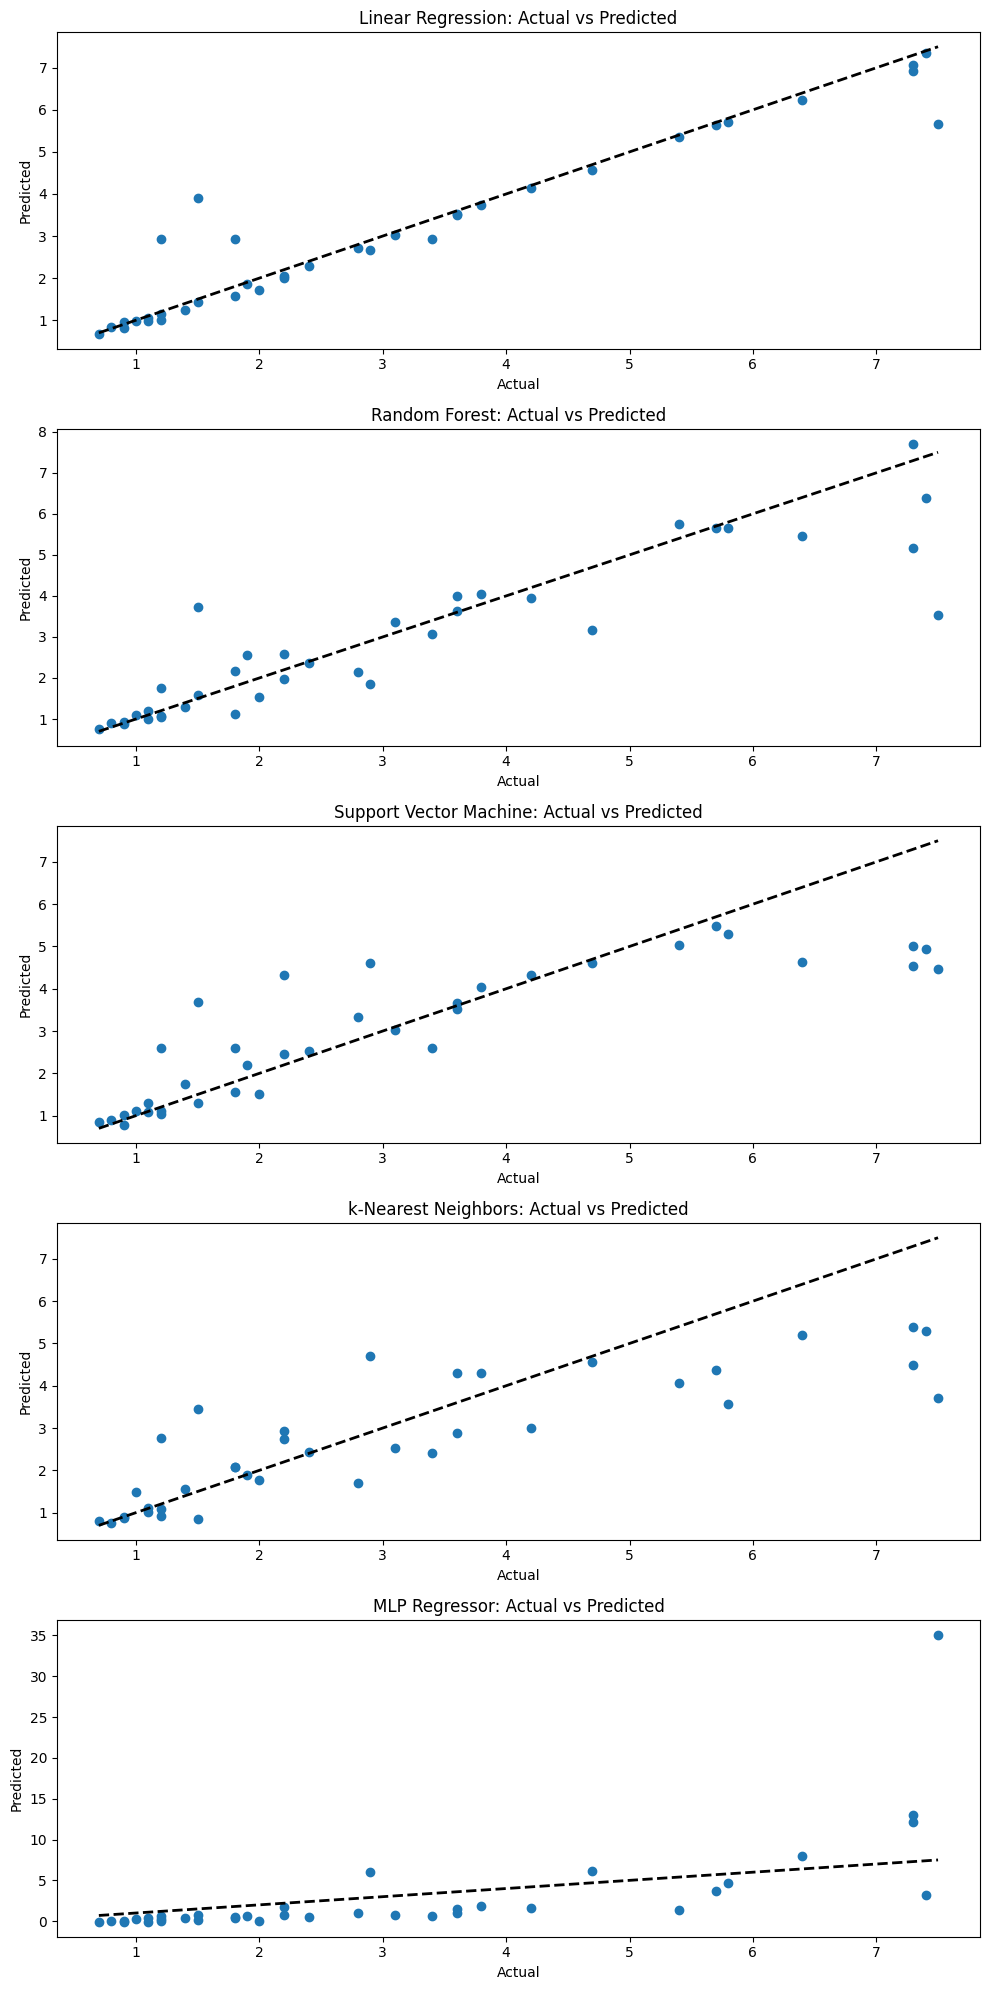

In [ ]:
import matplotlib.pyplot as plt

# Create subplots
fig, axes = plt.subplots(5, 1, figsize=(10, 20))

# Plot actual vs predicted values for Linear Regression
axes[0].scatter(y_test, y_pred_test)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

# Plot actual vs predicted values for Random Forest
axes[1].scatter(y_test, y_pred_test_rf)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[1].set_title('Random Forest: Actual vs Predicted')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

# Plot actual vs predicted values for Support Vector Machine
axes[2].scatter(y_test, y_pred_test_svm)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[2].set_title('Support Vector Machine: Actual vs Predicted')
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')

# Plot actual vs predicted values for k-Nearest Neighbors
axes[3].scatter(y_test, y_pred_test_knn)
axes[3].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[3].set_title('k-Nearest Neighbors: Actual vs Predicted')
axes[3].set_xlabel('Actual')
axes[3].set_ylabel('Predicted')

# Plot actual vs predicted values for MLP Regressor
axes[4].scatter(y_test, y_pred_test_mlp)
axes[4].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[4].set_title('MLP Regressor: Actual vs Predicted')
axes[4].set_xlabel('Actual')
axes[4].set_ylabel('Predicted')

plt.tight_layout()
plt.show()
